# Cervical Cancer Risk — Exploratory Data Analysis

This notebook investigates the cervical-cancer risk-factor dataset before any
predictive model is trained. The goal is to understand what one row represents,
how missing values are encoded, whether the target is imbalanced, and which
patterns deserve attention during modeling.

**Why EDA is separate from modeling:** exploration asks questions about the data,
while modeling estimates performance on unseen data. Keeping them separate makes
the workflow easier to audit and reduces the temptation to tune a model using the
test set.

> This is an educational project, not a medical diagnostic system.

## 1. Imports and display configuration

We use pandas for tabular analysis, NumPy for numerical operations, and
seaborn/matplotlib for plots. A fixed visual theme keeps figures consistent in
the notebook and in the project documentation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

# Resolve paths from either the project directory or its parent repository.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "cervical_cancer.csv").exists():
    PROJECT_DIR = PROJECT_DIR / "001_Cervical_Cancer_Predection_with_ML"

DATA_PATH = PROJECT_DIR / "data" / "cervical_cancer.csv"
ASSET_DIR = PROJECT_DIR / "docs" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATA_PATH.resolve()}")

Dataset: D:\Ck\Programming\github\machine-learning-projects\001_Cervical_Cancer_Predection_with_ML\data\cervical_cancer.csv


## 2. Load the raw dataset

Values are loaded as provided so we can inspect the source representation before
cleaning it. In this dataset, a question mark (`?`) means “not recorded”; pandas
does not recognize that token as missing unless we tell it to.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}")
raw.head()

Rows: 858 | Columns: 36


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


## 3. Define the prediction target and leakage boundary

`Biopsy` is the binary outcome: `1` means a positive biopsy result and `0` means
a negative result. Other screening and diagnosis outcomes are excluded from the
eventual predictor because they happen at roughly the same clinical stage—or
later—and could reveal the answer rather than represent an earlier risk factor.

In [3]:
TARGET = "Biopsy"
LEAKAGE_COLUMNS = [
    "Hinselmann", "Schiller", "Citology",
    "Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx",
]

print("Target:", TARGET)
print("Excluded from risk-factor modeling:", ", ".join(LEAKAGE_COLUMNS))

Target: Biopsy
Excluded from risk-factor modeling: Hinselmann, Schiller, Citology, Dx:Cancer, Dx:CIN, Dx:HPV, Dx


## 4. Convert the missing-value marker and numeric columns

Every feature is conceptually numeric, but the `?` marker causes pandas to store
many columns as generic objects. Replacing `?` with `NaN` and coercing values to
numbers enables valid summaries, correlations, imputers, and models. Coercion is
intentionally explicit: unexpected text becomes missing instead of silently
participating in calculations.

In [4]:
data = raw.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

quality_summary = pd.DataFrame(
    {
        "dtype_before": raw.dtypes.astype(str),
        "dtype_after": data.dtypes.astype(str),
        "missing_count": data.isna().sum(),
        "missing_percent": data.isna().mean().mul(100).round(2),
        "unique_values": data.nunique(dropna=True),
    }
).sort_values("missing_percent", ascending=False)

quality_summary.head(12)

,dtype_before,dtype_after,missing_count,missing_percent,unique_values
STDs: Time since last diagnosis,object,float64,787,91.72,18
STDs: Time since first diagnosis,object,float64,787,91.72,18
IUD,object,float64,117,13.64,2
IUD (years),object,float64,117,13.64,26
Hormonal Contraceptives,object,float64,108,12.59,2
Hormonal Contraceptives (years),object,float64,108,12.59,40
STDs:pelvic inflammatory disease,object,float64,105,12.24,2
STDs:vulvo-perineal condylomatosis,object,float64,105,12.24,2
STDs:HPV,object,float64,105,12.24,2
STDs:Hepatitis B,object,float64,105,12.24,2


## 5. Validate basic data integrity

These checks catch accidental dataset replacement, duplicate rows, invalid target
labels, and impossible ages early. Assertions are useful because a notebook that
merely runs is not necessarily analyzing the intended data.

In [5]:
assert TARGET in data.columns, "The expected target column is missing."
assert set(data[TARGET].dropna().unique()).issubset({0, 1}), "Target must be binary."
assert data["Age"].between(0, 120).all(), "Age contains an implausible value."

print(f"Duplicate rows: {data.duplicated().sum():,}")
print(f"Completely empty columns: {data.isna().all().sum():,}")
print(f"Target missing values: {data[TARGET].isna().sum():,}")

Duplicate rows: 23
Completely empty columns: 0
Target missing values: 0


## 6. Missing-data profile

Missingness matters because deleting incomplete rows can disproportionately remove
certain patient groups and shrink an already small positive class. We visualize
the most incomplete variables and later use median imputation fitted only on the
training data.

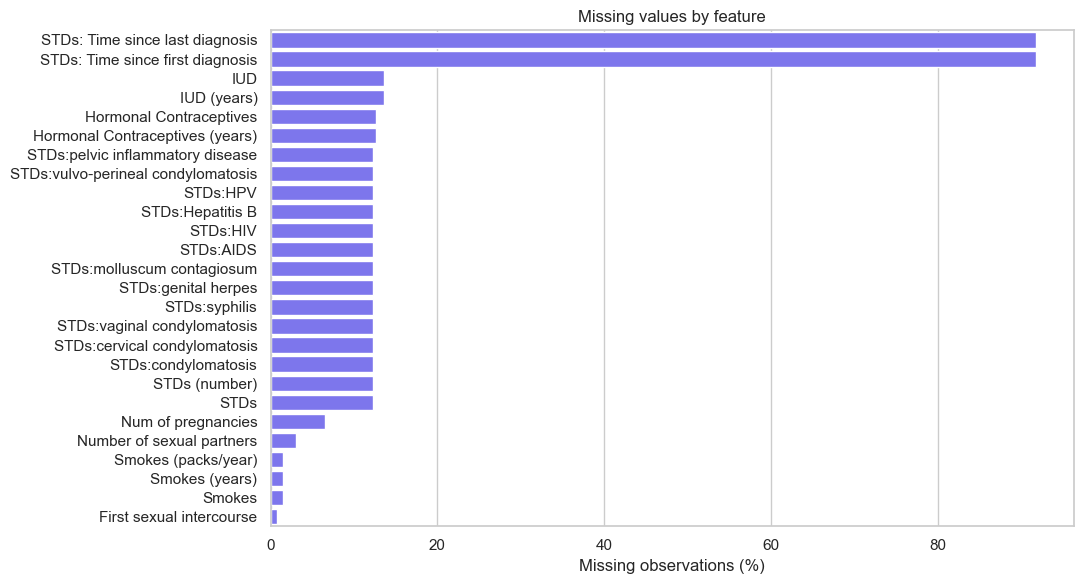

In [6]:
missing = data.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=missing.values, y=missing.index, color="#6C63FF", ax=ax)
ax.set(title="Missing values by feature", xlabel="Missing observations (%)", ylabel="")
fig.tight_layout()
fig.savefig(ASSET_DIR / "missing_values.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Target balance

Medical-event datasets are often imbalanced. Accuracy can therefore be misleading:
a model predicting only the majority class may appear accurate while detecting no
positive cases. This distribution determines our stratified split, class weighting,
and emphasis on recall and precision–recall AUC.

,count,percent
Biopsy,,
0,803,93.59
1,55,6.41


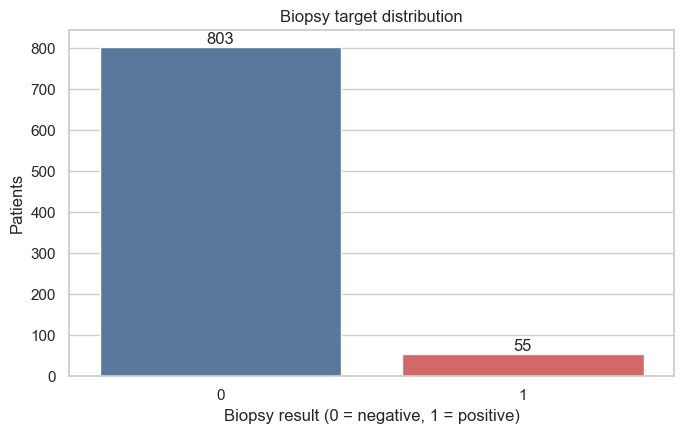

In [7]:
target_counts = data[TARGET].value_counts().sort_index()
target_percent = data[TARGET].value_counts(normalize=True).sort_index().mul(100)
display(pd.DataFrame({"count": target_counts, "percent": target_percent.round(2)}))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=data, x=TARGET, hue=TARGET, palette=["#4C78A8", "#E45756"], legend=False, ax=ax)
ax.set(title="Biopsy target distribution", xlabel="Biopsy result (0 = negative, 1 = positive)", ylabel="Patients")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(ASSET_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Patient age distribution

Age is inspected both overall and by biopsy outcome. This reveals the population
represented by the dataset and whether a simple demographic shift is visible.
The plot is descriptive only; overlapping distributions do not prove that age is
irrelevant once other factors are considered.

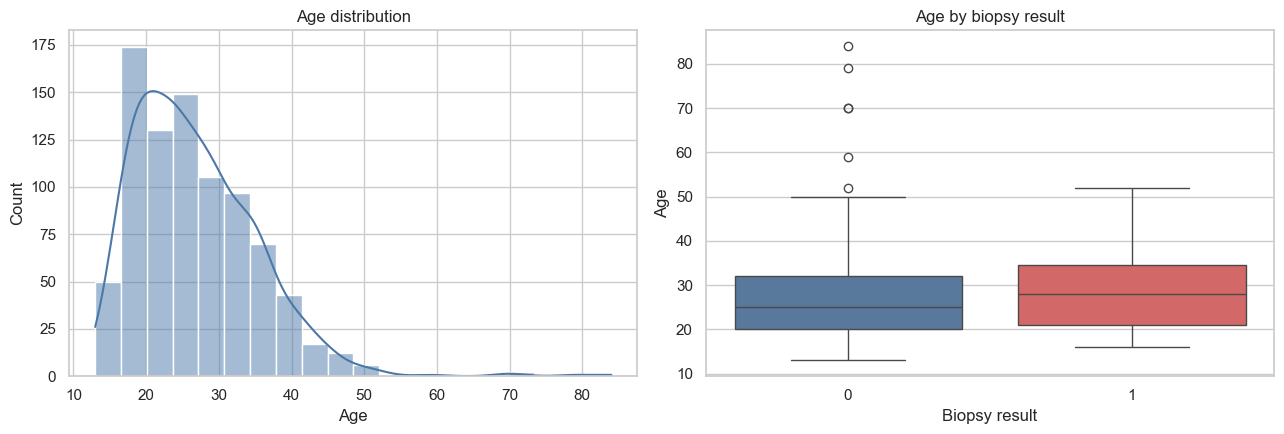

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=data, x="Age", bins=20, kde=True, color="#4C78A8", ax=axes[0])
axes[0].set_title("Age distribution")
sns.boxplot(data=data, x=TARGET, y="Age", hue=TARGET, palette=["#4C78A8", "#E45756"], legend=False, ax=axes[1])
axes[1].set_title("Age by biopsy result")
axes[1].set_xlabel("Biopsy result")
fig.tight_layout()
fig.savefig(ASSET_DIR / "age_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Selected behavioral and reproductive factors

We compare interpretable, pre-diagnostic variables rather than every column at
once. Median values are shown because several measures are skewed and contain
outliers. These summaries identify hypotheses; they do not establish causation.

In [9]:
selected_features = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Hormonal Contraceptives (years)",
    "IUD (years)",
    "STDs (number)",
]

group_summary = data.groupby(TARGET)[selected_features].median().T
group_summary.columns = ["Biopsy negative (median)", "Biopsy positive (median)"]
group_summary

,Biopsy negative (median),Biopsy positive (median)
Age,25.0,28.0
Number of sexual partners,2.0,2.0
First sexual intercourse,17.0,17.0
Num of pregnancies,2.0,2.5
Smokes (years),0.0,0.0
Hormonal Contraceptives (years),0.5,0.5
IUD (years),0.0,0.0
STDs (number),0.0,0.0


## 10. Correlation overview for risk-factor features

Correlation can reveal redundant variables and broad linear relationships. We
exclude diagnostic leakage fields and constant columns. Correlation is not
causation, and low linear correlation does not rule out a nonlinear association.

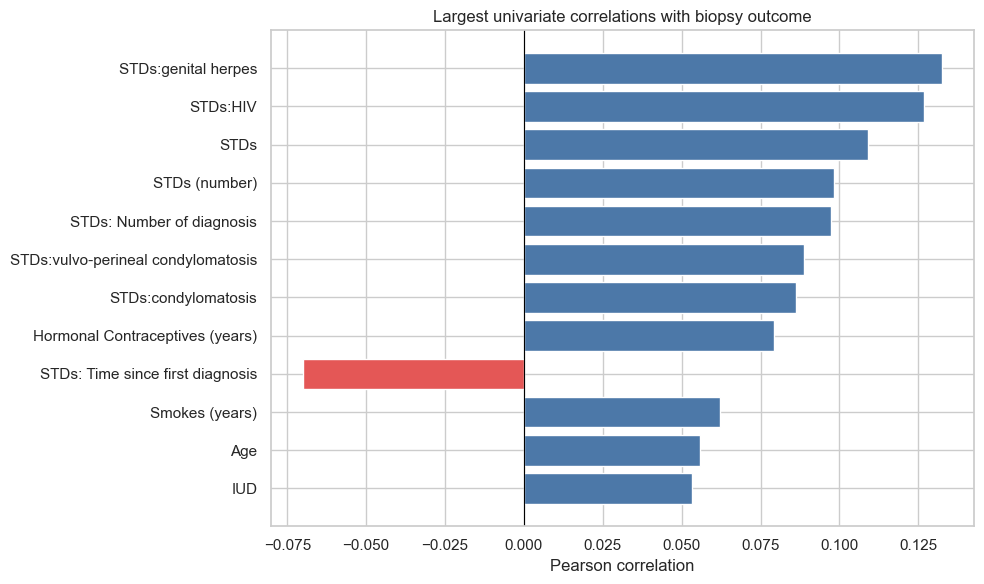

In [10]:
risk_features = [c for c in data.columns if c not in [TARGET, *LEAKAGE_COLUMNS]]
correlation_data = data[risk_features + [TARGET]].dropna(axis=1, how="all")
target_correlations = (
    correlation_data.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E45756" if value < 0 else "#4C78A8" for value in target_correlations.values]
ax.barh(target_correlations.index[::-1], target_correlations.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Largest univariate correlations with biopsy outcome", xlabel="Pearson correlation", ylabel="")
fig.tight_layout()
fig.savefig(ASSET_DIR / "target_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. EDA conclusions and modeling decisions

The analysis leads to the following decisions:

1. Replace `?` with missing values and impute inside a model pipeline.
2. Keep every row; dropping incomplete records would waste data and may add bias.
3. Use `Biopsy` as the target and remove contemporaneous diagnosis fields.
4. Use a stratified train/test split because positive biopsies are uncommon.
5. Compare a transparent logistic-regression baseline with a nonlinear random forest.
6. Prioritize recall, precision, F1, ROC-AUC, and PR-AUC over raw accuracy.
7. Treat all results as educational evidence, not clinical validation.

In [11]:
eda_summary = {
    "rows": int(data.shape[0]),
    "columns": int(data.shape[1]),
    "positive_biopsies": int(data[TARGET].sum()),
    "positive_rate_percent": round(float(data[TARGET].mean() * 100), 2),
    "columns_with_missing_values": int((data.isna().sum() > 0).sum()),
    "duplicate_rows": int(data.duplicated().sum()),
}
eda_summary

{'rows': 858,
 'columns': 36,
 'positive_biopsies': 55,
 'positive_rate_percent': 6.41,
 'columns_with_missing_values': 26,
 'duplicate_rows': 23}